# Cyberpunk 2077 on RX 5500XT (With FG = ON)

In [137]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("Cyberpunk2077_2026-05-23_21-28-19.csv")
df

,fps,frametime,cpu_load,cpu_power,gpu_load,cpu_temp,gpu_temp,gpu_core_clock,gpu_mem_clock,gpu_vram_used,gpu_power,ram_used,swap_used,process_rss,cpu_mhz,elapsed
0,61.1336,16.3576,34.0033,0,80,62,53,1237,875,3.66100,49,5.43666,0,2.87341,4341,1284767324
1,59.0810,16.9259,33.7815,0,78,62,53,1317,875,3.66100,48,5.43666,0,2.87341,4341,2285233252
2,61.2225,16.3339,34.6154,0,79,62,53,1233,875,3.66109,49,5.43690,0,2.87341,4341,3285326110
3,61.5976,16.2344,34.0604,0,80,62,53,1230,875,3.66100,48,5.43715,0,2.87342,4338,4285413348
4,61.1766,16.3461,34.7245,0,78,62,53,1370,875,3.66173,48,5.43715,0,2.87342,4340,5285512749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2425,60.2738,16.5910,39.8649,0,80,68,66,1176,875,5.18126,51,6.35835,0,3.75414,4266,2426400809449
2426,60.2112,16.6082,40.5229,0,78,68,66,1349,875,5.18144,51,6.35764,0,3.75414,4266,2427400856501
2427,60.1671,16.6204,40.4362,0,82,68,66,1215,875,5.18126,52,6.35609,0,3.75414,4291,2428400900417
2428,60.1463,16.6261,41.4075,0,79,68,66,1244,875,5.18163,50,6.35491,0,3.75304,4231,2429400943462


In [138]:
display(df.sample(5))
print(df.info())
display(df.describe())
df.shape

,fps,frametime,cpu_load,cpu_power,gpu_load,cpu_temp,gpu_temp,gpu_core_clock,gpu_mem_clock,gpu_vram_used,gpu_power,ram_used,swap_used,process_rss,cpu_mhz,elapsed
791,61.7664,16.1900,32.0786,0,78,67,66,1418,875,3.89539,64,5.59703,0,3.02674,4316,792313705696
915,61.3046,16.3120,32.4013,0,79,66,67,1500,875,3.77374,55,5.58723,0,3.02410,4316,916321517915
2173,60.5424,16.5174,38.2353,0,80,68,67,1302,875,5.02962,52,6.28815,0,3.66273,4295,2174389401452
1236,60.9996,16.3936,36.7213,0,79,68,69,1594,875,3.96981,71,5.60409,0,3.03963,4341,1237340482143
919,61.5848,16.2378,33.3333,0,79,66,67,1446,875,3.77330,57,5.58844,0,3.02411,4316,920321740759


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2430 entries, 0 to 2429
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fps             2430 non-null   float64
 1   frametime       2430 non-null   float64
 2   cpu_load        2430 non-null   float64
 3   cpu_power       2430 non-null   int64  
 4   gpu_load        2430 non-null   int64  
 5   cpu_temp        2430 non-null   int64  
 6   gpu_temp        2430 non-null   int64  
 7   gpu_core_clock  2430 non-null   int64  
 8   gpu_mem_clock   2430 non-null   int64  
 9   gpu_vram_used   2430 non-null   float64
 10  gpu_power       2430 non-null   int64  
 11  ram_used        2430 non-null   float64
 12  swap_used       2430 non-null   int64  
 13  process_rss     2430 non-null   float64
 14  cpu_mhz         2430 non-null   int64  
 15  elapsed         2430 non-null   int64  
dtypes: float64(6), int64(10)
memory usage: 303.9 KB
None


,fps,frametime,cpu_load,cpu_power,gpu_load,cpu_temp,gpu_temp,gpu_core_clock,gpu_mem_clock,gpu_vram_used,gpu_power,ram_used,swap_used,process_rss,cpu_mhz,elapsed
count,2430.000000,2430.000000,2430.000000,2430.0,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.0,2430.000000,2430.000000,2.430000e+03
mean,62.913648,16.683877,37.520913,0.0,79.072428,66.855556,65.600000,1344.055556,874.932099,4.182333,58.463786,5.723085,0.0,3.144747,4302.628395,1.215840e+12
std,55.160110,1.342917,4.456314,0.0,4.624084,1.279457,2.947126,190.169504,1.435565,0.422028,8.755127,0.267866,0.0,0.248966,30.157262,7.016591e+11
min,29.907100,0.639419,20.813000,0.0,24.000000,62.000000,53.000000,45.000000,825.000000,3.657220,22.000000,5.430890,0.0,2.873410,4194.000000,1.284767e+09
25%,59.626100,16.400250,34.150300,0.0,79.000000,66.000000,65.000000,1252.000000,875.000000,3.860520,53.000000,5.583058,0.0,3.014292,4283.000000,6.085552e+11
50%,60.062850,16.649250,36.641800,0.0,79.000000,67.000000,66.000000,1353.000000,875.000000,4.102740,58.000000,5.606395,0.0,3.038560,4312.000000,1.215840e+12
75%,60.974725,16.771150,40.098200,0.0,80.000000,68.000000,67.000000,1451.000000,875.000000,4.310220,64.000000,5.771205,0.0,3.192960,4317.000000,1.823120e+12
max,1563.920000,33.436900,60.392800,0.0,87.000000,69.000000,70.000000,1845.000000,875.000000,5.217350,96.000000,6.450290,0.0,3.781800,4419.000000,2.430401e+12


(2430, 16)

(np.float64(0.0), np.float64(120.0), np.float64(0.0), np.float64(0.035))

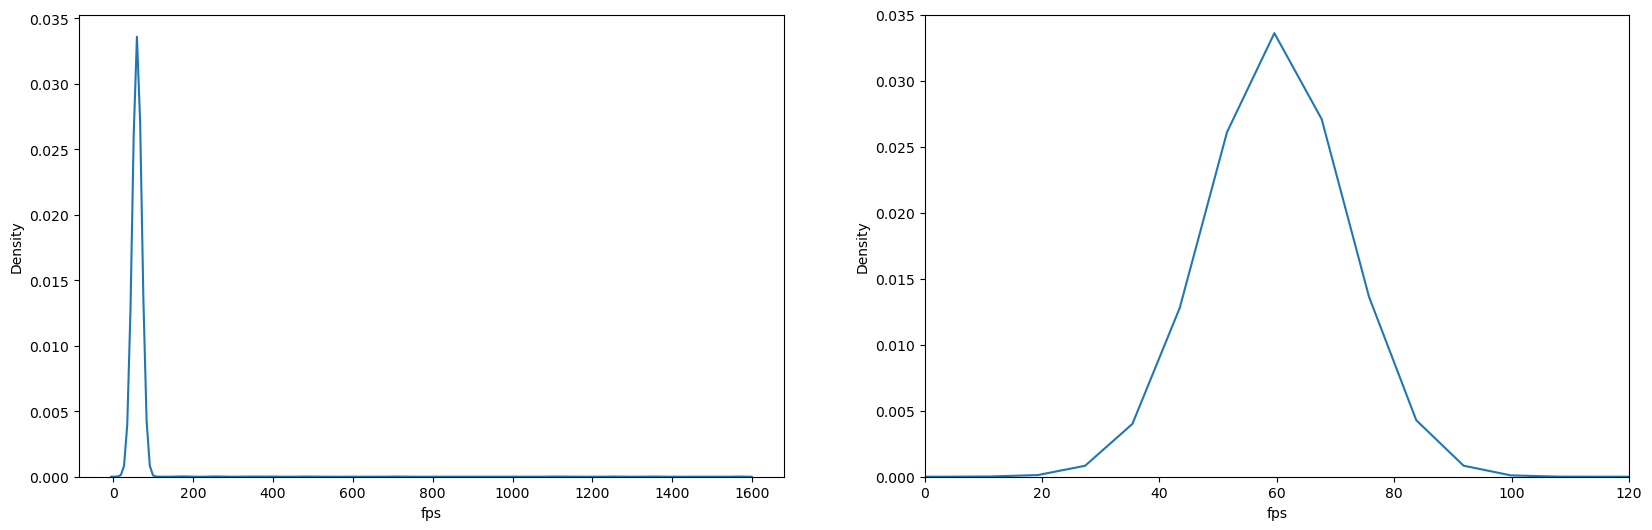

In [139]:
plt.figure(figsize=(20,6))
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x="fps")
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x="fps")
plt.axis([0, 120,0,0.035])

# Drop Outliers:

In [140]:
mean = df["fps"].mean()
std = df["fps"].std()
df["z_score"] = (df["fps"]-mean)/std
dfOutLiers = df[abs(df["z_score"])>3]
print(len(dfOutLiers))
dfOutLiers

11


,fps,frametime,cpu_load,cpu_power,gpu_load,cpu_temp,gpu_temp,gpu_core_clock,gpu_mem_clock,gpu_vram_used,gpu_power,ram_used,swap_used,process_rss,cpu_mhz,elapsed,z_score
540,262.319,3.812150,42.0455,0,79,67,65,1411,875,4.09791,61,5.55537,0,2.99649,4267,541303692199,3.615028
575,704.174,1.420100,42.4144,0,80,66,64,1446,875,4.10624,57,5.56117,0,2.99606,4266,576304523872,11.625436
585,248.362,4.026380,43.0894,0,81,66,65,1205,875,4.11260,64,5.56810,0,3.00505,4266,586304758914,3.362001
588,1353.650,0.738745,41.7508,0,80,66,65,1368,875,4.17765,62,5.57681,0,3.00769,4267,589304821403,23.399815
597,320.392,3.121170,40.1639,0,82,66,65,1148,875,4.19501,58,5.58867,0,3.01348,4291,598304987963,4.667836
603,479.656,2.084830,39.2857,0,80,66,65,1397,875,4.18402,58,5.58204,0,3.01273,4291,604305128451,7.555140
630,1100.710,0.908504,37.8512,0,79,67,66,1324,875,4.12404,60,5.58962,0,3.01814,4291,631305769614,18.814255
632,1563.920,0.639419,38.1729,0,80,67,65,1209,875,4.10977,48,5.59278,0,3.01607,4308,633305812563,27.211809
1954,1251.710,0.798908,36.5971,0,79,67,66,1219,875,4.26213,49,5.76963,0,3.19835,4291,1955377519102,21.551740
1956,354.696,2.819320,39.5310,0,80,67,66,1179,875,4.26739,54,5.77217,0,3.19835,4263,1957377631931,5.289735


In [141]:
df = df[abs(df["z_score"])<3]
df

,fps,frametime,cpu_load,cpu_power,gpu_load,cpu_temp,gpu_temp,gpu_core_clock,gpu_mem_clock,gpu_vram_used,gpu_power,ram_used,swap_used,process_rss,cpu_mhz,elapsed,z_score
0,61.1336,16.3576,34.0033,0,80,62,53,1237,875,3.66100,49,5.43666,0,2.87341,4341,1284767324,-0.032271
1,59.0810,16.9259,33.7815,0,78,62,53,1317,875,3.66100,48,5.43666,0,2.87341,4341,2285233252,-0.069482
2,61.2225,16.3339,34.6154,0,79,62,53,1233,875,3.66109,49,5.43690,0,2.87341,4341,3285326110,-0.030659
3,61.5976,16.2344,34.0604,0,80,62,53,1230,875,3.66100,48,5.43715,0,2.87342,4338,4285413348,-0.023859
4,61.1766,16.3461,34.7245,0,78,62,53,1370,875,3.66173,48,5.43715,0,2.87342,4340,5285512749,-0.031491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2425,60.2738,16.5910,39.8649,0,80,68,66,1176,875,5.18126,51,6.35835,0,3.75414,4266,2426400809449,-0.047858
2426,60.2112,16.6082,40.5229,0,78,68,66,1349,875,5.18144,51,6.35764,0,3.75414,4266,2427400856501,-0.048993
2427,60.1671,16.6204,40.4362,0,82,68,66,1215,875,5.18126,52,6.35609,0,3.75414,4291,2428400900417,-0.049792
2428,60.1463,16.6261,41.4075,0,79,68,66,1244,875,5.18163,50,6.35491,0,3.75304,4231,2429400943462,-0.050169


,fps,frametime,cpu_load,cpu_power,gpu_load,cpu_temp,gpu_temp,gpu_core_clock,gpu_mem_clock,gpu_vram_used,gpu_power,ram_used,swap_used,process_rss,cpu_mhz,elapsed,z_score
count,2419.000000,2419.000000,2419.000000,2419.0,2419.000000,2419.000000,2419.000000,2419.000000,2419.000000,2419.000000,2419.000000,2419.000000,2419.0,2419.000000,2419.000000,2.419000e+03,2419.000000
mean,59.878173,16.750278,37.505936,0.0,79.066970,66.856552,65.600248,1344.140554,874.931790,4.182155,58.460521,5.723356,0.0,3.144995,4302.736668,1.216911e+12,-0.055030
std,3.967453,0.911391,4.456222,0.0,4.633158,1.281545,2.952648,190.334752,1.438819,0.422781,8.757626,0.268202,0.0,0.249279,30.165982,7.017854e+11,0.071926
min,29.907100,5.776130,20.813000,0.0,24.000000,62.000000,53.000000,45.000000,825.000000,3.657220,22.000000,5.430890,0.0,2.873410,4194.000000,1.284767e+09,-0.598377
25%,59.622200,16.403200,34.144350,0.0,79.000000,66.000000,65.000000,1252.000000,875.000000,3.860500,53.000000,5.583605,0.0,3.014515,4284.000000,6.118053e+11,-0.059671
50%,60.059500,16.650200,36.617400,0.0,79.000000,67.000000,66.000000,1353.000000,875.000000,4.102060,58.000000,5.606510,0.0,3.038590,4312.000000,1.218340e+12,-0.051743
75%,60.963750,16.772300,40.066200,0.0,80.000000,68.000000,67.000000,1451.000000,875.000000,4.310645,64.000000,5.771295,0.0,3.192960,4317.000000,1.822870e+12,-0.035350
max,173.126000,33.436900,60.392800,0.0,87.000000,69.000000,70.000000,1845.000000,875.000000,5.217350,96.000000,6.450290,0.0,3.781800,4419.000000,2.430401e+12,1.998044


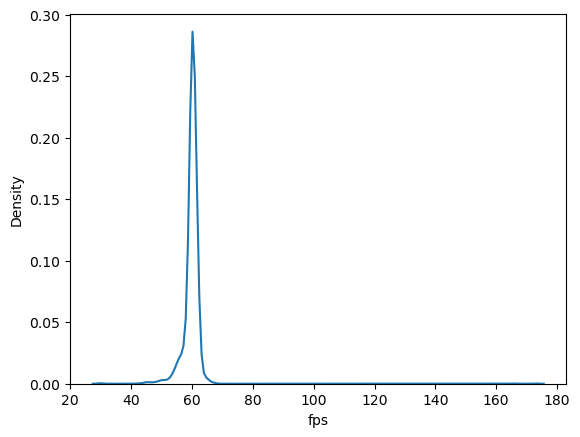

In [142]:
sns.kdeplot(data=df, x= "fps")
display(df.describe())
plt.show()

# Frame rate was cappet at 60fps:

In [143]:
df = df[df["fps"]<70] #Some time fps get over fps limit
df

,fps,frametime,cpu_load,cpu_power,gpu_load,cpu_temp,gpu_temp,gpu_core_clock,gpu_mem_clock,gpu_vram_used,gpu_power,ram_used,swap_used,process_rss,cpu_mhz,elapsed,z_score
0,61.1336,16.3576,34.0033,0,80,62,53,1237,875,3.66100,49,5.43666,0,2.87341,4341,1284767324,-0.032271
1,59.0810,16.9259,33.7815,0,78,62,53,1317,875,3.66100,48,5.43666,0,2.87341,4341,2285233252,-0.069482
2,61.2225,16.3339,34.6154,0,79,62,53,1233,875,3.66109,49,5.43690,0,2.87341,4341,3285326110,-0.030659
3,61.5976,16.2344,34.0604,0,80,62,53,1230,875,3.66100,48,5.43715,0,2.87342,4338,4285413348,-0.023859
4,61.1766,16.3461,34.7245,0,78,62,53,1370,875,3.66173,48,5.43715,0,2.87342,4340,5285512749,-0.031491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2425,60.2738,16.5910,39.8649,0,80,68,66,1176,875,5.18126,51,6.35835,0,3.75414,4266,2426400809449,-0.047858
2426,60.2112,16.6082,40.5229,0,78,68,66,1349,875,5.18144,51,6.35764,0,3.75414,4266,2427400856501,-0.048993
2427,60.1671,16.6204,40.4362,0,82,68,66,1215,875,5.18126,52,6.35609,0,3.75414,4291,2428400900417,-0.049792
2428,60.1463,16.6261,41.4075,0,79,68,66,1244,875,5.18163,50,6.35491,0,3.75304,4231,2429400943462,-0.050169


,fps,frametime,cpu_load,cpu_power,gpu_load,cpu_temp,gpu_temp,gpu_core_clock,gpu_mem_clock,gpu_vram_used,gpu_power,ram_used,swap_used,process_rss,cpu_mhz,elapsed,z_score
count,2417.000000,2417.000000,2417.000000,2417.0,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.0,2417.00000,2417.000000,2.417000e+03,2417.000000
mean,59.787304,16.759260,37.500749,0.0,79.066198,66.856020,65.599090,1344.072818,874.931734,4.181841,58.458006,5.723183,0.0,3.14484,4302.761274,1.216757e+12,-0.056678
std,2.398507,0.856556,4.453202,0.0,4.634997,1.281861,2.953035,190.386709,1.439413,0.422626,8.757400,0.268061,0.0,0.24916,30.163237,7.017262e+11,0.043483
min,29.907100,14.812600,20.813000,0.0,24.000000,62.000000,53.000000,45.000000,825.000000,3.657220,22.000000,5.430890,0.0,2.87341,4194.000000,1.284767e+09,-0.598377
25%,59.621500,16.403900,34.142400,0.0,79.000000,66.000000,65.000000,1252.000000,875.000000,3.860500,53.000000,5.583570,0.0,3.01451,4284.000000,6.113053e+11,-0.059683
50%,60.058300,16.650500,36.605700,0.0,79.000000,67.000000,66.000000,1353.000000,875.000000,4.101970,58.000000,5.606510,0.0,3.03859,4312.000000,1.218340e+12,-0.051765
75%,60.961100,16.772500,40.033800,0.0,80.000000,68.000000,67.000000,1451.000000,875.000000,4.310530,64.000000,5.771220,0.0,3.19296,4317.000000,1.822370e+12,-0.035398
max,67.510200,33.436900,60.392800,0.0,87.000000,69.000000,70.000000,1845.000000,875.000000,5.217350,96.000000,6.450290,0.0,3.78180,4419.000000,2.430401e+12,0.083331


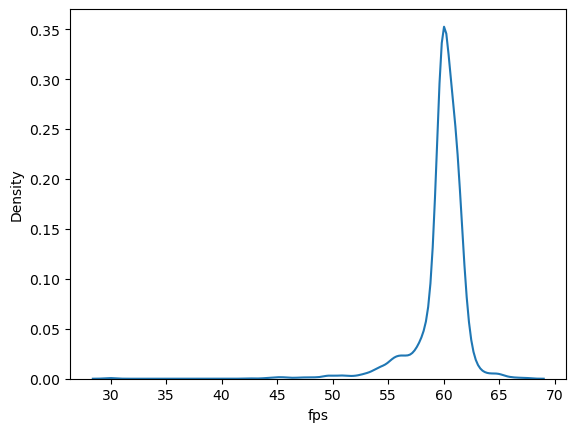

In [144]:
sns.kdeplot(data=df, x= "fps")
display(df.describe())
plt.show()

In [145]:
heightsFps = df[df["fps"]==67.510200]
display(heightsFps)
lowestsFps = df[df["fps"]==df["fps"].min()]
lowestsFps

,fps,frametime,cpu_load,cpu_power,gpu_load,cpu_temp,gpu_temp,gpu_core_clock,gpu_mem_clock,gpu_vram_used,gpu_power,ram_used,swap_used,process_rss,cpu_mhz,elapsed,z_score
2198,67.5102,14.8126,47.9132,0,77,68,67,864,875,5.09492,53,6.29545,0,3.68378,4267,2199390615040,0.083331


,fps,frametime,cpu_load,cpu_power,gpu_load,cpu_temp,gpu_temp,gpu_core_clock,gpu_mem_clock,gpu_vram_used,gpu_power,ram_used,swap_used,process_rss,cpu_mhz,elapsed,z_score
1970,29.9071,33.4369,37.5634,0,78,67,66,1106,875,4.27502,48,5.78567,0,3.20338,4291,1971378441026,-0.598377


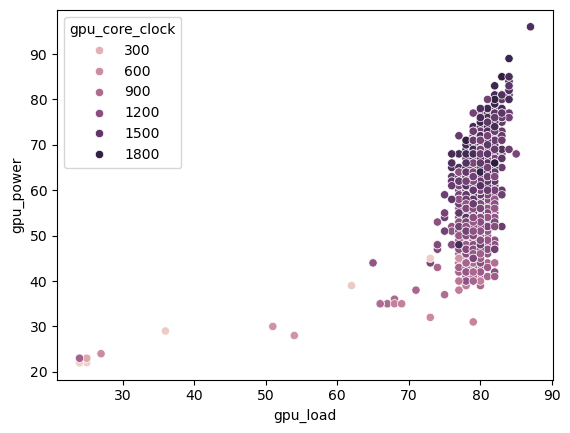

In [146]:
sns.scatterplot(data=df, x="gpu_load", y="gpu_power", hue="gpu_core_clock")
plt.show()

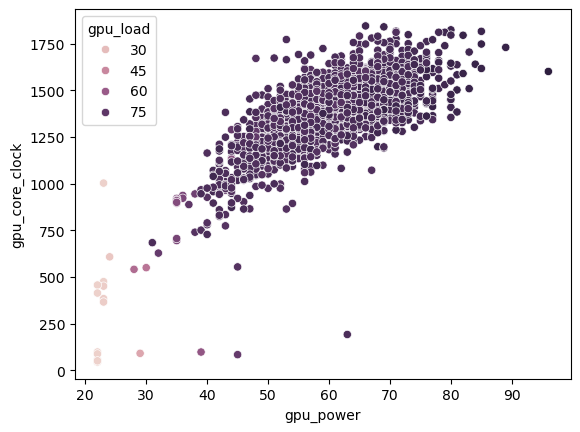

In [147]:
sns.scatterplot(data=df, x="gpu_power", y="gpu_core_clock", hue="gpu_load")
plt.show()

In [148]:
df.corr()[["fps", "gpu_core_clock", "gpu_power", "cpu_load", "gpu_load"]].sort_values(by="fps", ascending=False)

,fps,gpu_core_clock,gpu_power,cpu_load,gpu_load
fps,1.000000,-0.051903,-0.058052,-0.042194,-0.028105
z_score,1.000000,-0.051903,-0.058052,-0.042194,-0.028105
elapsed,0.067470,0.031981,0.168574,0.410855,-0.039840
process_rss,0.049748,0.048621,0.144121,0.649821,0.020289
ram_used,0.048876,0.050223,0.147065,0.656027,0.017565
gpu_temp,0.045561,0.262746,0.455103,0.324189,0.101037
gpu_vram_used,0.029932,0.036297,0.118583,0.674638,0.019561
cpu_temp,0.024413,0.109718,0.242958,0.420099,0.033093
cpu_mhz,0.016376,-0.151460,-0.234000,-0.661945,-0.078238
gpu_mem_clock,-0.015638,0.076430,0.079874,0.017882,0.135055


<Axes: ylabel='fps'>

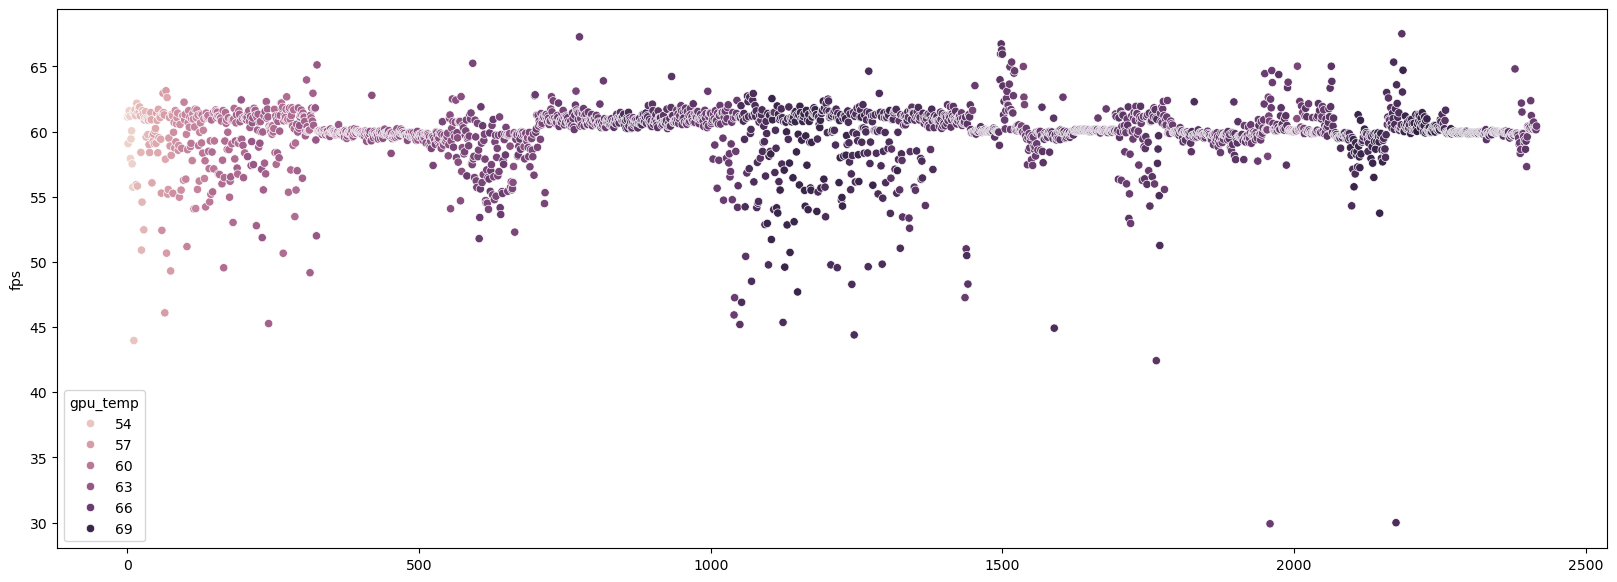

In [149]:
plt.figure(figsize=(20,7))
sns.scatterplot(data=df, x=np.arange(0, df.shape[0]), y="fps", hue="gpu_temp")

<Axes: xlabel='gpu_power', ylabel='gpu_temp'>

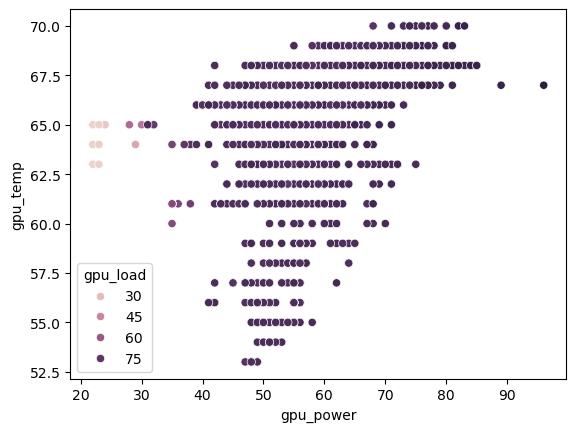

In [150]:
sns.scatterplot(data=df, x= "gpu_power", y="gpu_temp", hue="gpu_load")